# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Jhon Eibert Escobar  <br>
Url: https://github.com/jhonescobar/MIAR-Algoritmos-de-Optimizacion<br>
Google Colab: https://colab.research.google.com/drive/1MKRW6kjRwhyAPO6H2cTSAFn4VWE5SG_u?usp=sharing <br>
Problema:
>Organizar los horarios de partidos de una jornada de La Liga<br>

Descripción del problema:
Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la audiencia.

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

In [1]:
#Respuesta
# Respuesta Modelo
"""
ESPACIO DE SOLUCIONES:
Una solución se representa como una lista de 10 elementos, donde cada elemento
es un horario asignado a uno de los 10 partidos de la jornada.
Cada horario se codifica como una tupla (día, hora):
  - ('V', 20), ('S', 12), ('S', 16), ('S', 18), ('S', 20),
    ('D', 12), ('D', 16), ('D', 18), ('D', 20), ('L', 20)
Ejemplo de solución: [('V',20), ('S',12), ('S',20), ('D',16), ('D',20),
                       ('S',18), ('D',18), ('L',20), ('S',16), ('D',12)]

FUNCIÓN OBJETIVO:
Maximizar la audiencia total de la jornada:
  f(solución) = Σ [ audiencia_base(partido_i) × ponderación(horario_i) × corrección_coincidencia(horario_i) ]
  Para cada partido i de 0 a 9.

RESTRICCIONES:
  1. Exactamente 1 partido debe jugarse el Viernes a las 20h.
  2. Exactamente 1 partido debe jugarse el Lunes a las 20h.
  3. Los 8 partidos restantes se asignan a horarios de Sábado o Domingo.
  4. Puede haber coincidencia de horarios (varios partidos en el mismo slot),
     pero eso penaliza la audiencia según la tabla de coincidencias.
"""
print("Modelo definido correctamente.")

Modelo definido correctamente.


#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

In [2]:
#Respuesta
import math

"""
COMPLEJIDAD DEL PROBLEMA:

Tenemos 10 partidos y 9 horarios posibles (V20, S12, S16, S18, S20, D12, D16, D18, D20, L20).
Sin restricciones, el número de asignaciones posibles sería: 9^10

Con las restricciones (1 partido fijo en Viernes, 1 en Lunes, 8 en Sab/Dom):
  - Elegir qué partido va el Viernes: C(10,1) = 10
  - Elegir qué partido va el Lunes: C(9,1) = 9
  - Asignar los 8 restantes a 7 horarios (S12,S16,S18,S20,D12,D16,D18,D20): 7^8
  - Total: 10 × 9 × 7^8
"""

sin_restricciones = 9**10
con_restricciones = 10 * 9 * (7**8)

print(f"Espacio de soluciones sin restricciones: 9^10 = {sin_restricciones:,}")
print(f"Espacio de soluciones con restricciones: 10 × 9 × 7^8 = {con_restricciones:,}")
print()
print("Orden de complejidad: O(n^k) donde n=horarios y k=partidos → Problema NP")
print("Es un problema de asignación combinatoria. La búsqueda exhaustiva es inviable.")
print("Por eso se utiliza un Algoritmo Genético para explorar el espacio de soluciones.")

Espacio de soluciones sin restricciones: 9^10 = 3,486,784,401
Espacio de soluciones con restricciones: 10 × 9 × 7^8 = 518,832,090

Orden de complejidad: O(n^k) donde n=horarios y k=partidos → Problema NP
Es un problema de asignación combinatoria. La búsqueda exhaustiva es inviable.
Por eso se utiliza un Algoritmo Genético para explorar el espacio de soluciones.


#Diseño
- ¿Que técnica utilizo? ¿Por qué?

In [3]:
#Respuesta
"""
TÉCNICA: Algoritmo Genético (AG)

¿Por qué un Algoritmo Genético?
  1. El espacio de soluciones es muy grande (~40 millones de combinaciones válidas),
     por lo que la búsqueda exhaustiva es inviable.
  2. Los AGs son especialmente buenos para problemas de asignación combinatoria
     como este, donde hay múltiples restricciones y una función objetivo compleja.
  3. Permiten explorar diversas regiones del espacio de búsqueda gracias a la
     población de soluciones y los operadores de cruce y mutación.
  4. La función de aptitud (fitness) se puede diseñar fácilmente para incorporar
     tanto la maximización de audiencia como las penalizaciones por restricciones.

DISEÑO DEL AG:
  - Representación: Cada individuo es una lista de 10 horarios (uno por partido).
  - Población inicial: Generada aleatoriamente respetando las restricciones.
  - Fitness: Audiencia total calculada con base, ponderación y corrección por coincidencias.
  - Selección: Torneo de tamaño k=3.
  - Cruce: Cruce en un punto.
  - Mutación: Cambio aleatorio de un horario respetando restricciones.
  - Elitismo: Se conservan los mejores individuos entre generaciones.
"""
print("Diseño del Algoritmo Genético definido.")

Diseño del Algoritmo Genético definido.


## Implementación

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ─────────────────────────────────────────
# DATOS DEL PROBLEMA
# ─────────────────────────────────────────

# 20 equipos: 3 cat A, 11 cat B, 6 cat C
equipos = (
    ['A'] * 3 +
    ['B'] * 11 +
    ['C'] * 6
)

# Generar los 10 partidos de la jornada (emparejamiento)
# Usamos índices para identificar los equipos
indices = list(range(20))
random.seed(42)
random.shuffle(indices)
partidos = [(indices[i], indices[i+1]) for i in range(0, 20, 2)]

print("Partidos de la jornada:")
for i, (e1, e2) in enumerate(partidos):
    print(f"  Partido {i}: Equipo {e1} (Cat {equipos[e1]}) vs Equipo {e2} (Cat {equipos[e2]})")

Partidos de la jornada:
  Partido 0: Equipo 19 (Cat C) vs Equipo 5 (Cat B)
  Partido 1: Equipo 14 (Cat C) vs Equipo 4 (Cat B)
  Partido 2: Equipo 9 (Cat B) vs Equipo 13 (Cat B)
  Partido 3: Equipo 15 (Cat C) vs Equipo 18 (Cat C)
  Partido 4: Equipo 6 (Cat B) vs Equipo 12 (Cat B)
  Partido 5: Equipo 17 (Cat C) vs Equipo 10 (Cat B)
  Partido 6: Equipo 1 (Cat A) vs Equipo 11 (Cat B)
  Partido 7: Equipo 2 (Cat A) vs Equipo 16 (Cat C)
  Partido 8: Equipo 7 (Cat B) vs Equipo 8 (Cat B)
  Partido 9: Equipo 0 (Cat A) vs Equipo 3 (Cat B)


In [5]:
# ─────────────────────────────────────────
# TABLAS DEL PROBLEMA
# ─────────────────────────────────────────

# Audiencia base en millones (Sábado 20h, el mejor horario)
# Clave: frozenset de categorías del partido
audiencia_base = {
    ('A', 'A'): 2.0,
    ('A', 'B'): 1.3,
    ('A', 'C'): 1.0,
    ('B', 'B'): 0.9,
    ('B', 'C'): 0.75,
    ('C', 'C'): 0.6,   # Estimado (no aparece en enunciado)
}

def get_audiencia_base(e1, e2):
    """Obtiene la audiencia base de un partido según las categorías de los equipos."""
    cats = tuple(sorted([equipos[e1], equipos[e2]]))
    return audiencia_base.get(cats, 0.6)

# Ponderación por horario (día, hora)
ponderacion = {
    ('V', 20): 0.4,
    ('S', 12): 0.55,
    ('S', 16): 0.7,
    ('S', 18): 0.8,
    ('S', 20): 1.0,
    ('D', 12): 0.45,
    ('D', 16): 0.75,
    ('D', 18): 0.85,
    ('D', 20): 1.0,
    ('L', 20): 0.4,
}

# Horarios disponibles
HORARIOS_TODOS = list(ponderacion.keys())
HORARIOS_MID = [h for h in HORARIOS_TODOS if h[0] in ('S', 'D')]  # Solo Sáb/Dom

# Reducción de audiencia por coincidencias
# coincidencias: número de otros partidos en el mismo horario
reduccion_coincidencia = {
    0: 0.00,
    1: 0.25,
    2: 0.45,
    3: 0.60,
    4: 0.70,
    5: 0.75,
    6: 0.78,
    7: 0.80,
    8: 0.80,
}

print("Tablas del problema cargadas correctamente.")
print(f"Horarios disponibles: {HORARIOS_TODOS}")

Tablas del problema cargadas correctamente.
Horarios disponibles: [('V', 20), ('S', 12), ('S', 16), ('S', 18), ('S', 20), ('D', 12), ('D', 16), ('D', 18), ('D', 20), ('L', 20)]


In [6]:
# ─────────────────────────────────────────
# FUNCIÓN DE APTITUD (FITNESS)
# ─────────────────────────────────────────

def calcular_coincidencias(solucion):
    """Para cada partido, cuenta cuántos otros partidos tienen el mismo horario."""
    from collections import Counter
    conteo = Counter(solucion)
    return [conteo[h] - 1 for h in solucion]  # -1 porque no se cuenta a sí mismo

def fitness(solucion):
    """
    Calcula la audiencia total de la jornada dada una solución.
    solucion: lista de 10 horarios (tuplas (dia, hora)) para cada partido.
    """
    coincidencias = calcular_coincidencias(solucion)
    total = 0.0
    for i, (e1, e2) in enumerate(partidos):
        base = get_audiencia_base(e1, e2)
        pond = ponderacion[solucion[i]]
        coinc = min(coincidencias[i], 8)  # máximo 8 en la tabla
        reduccion = reduccion_coincidencia[coinc]
        audiencia_partido = base * pond * (1 - reduccion)
        total += audiencia_partido
    return total

def es_valida(solucion):
    """Verifica que la solución cumple las restricciones."""
    viernes = sum(1 for h in solucion if h == ('V', 20))
    lunes = sum(1 for h in solucion if h == ('L', 20))
    return viernes == 1 and lunes == 1

print("Función de aptitud definida.")

Función de aptitud definida.


In [7]:
# ─────────────────────────────────────────
# ALGORITMO GENÉTICO
# ─────────────────────────────────────────

def generar_individuo():
    """Genera una solución aleatoria válida."""
    solucion = [None] * 10
    # Asignar viernes y lunes a partidos aleatorios distintos
    idx_viernes = random.randint(0, 9)
    idx_lunes = random.randint(0, 9)
    while idx_lunes == idx_viernes:
        idx_lunes = random.randint(0, 9)
    solucion[idx_viernes] = ('V', 20)
    solucion[idx_lunes] = ('L', 20)
    # Asignar el resto a horarios de Sáb/Dom
    for i in range(10):
        if solucion[i] is None:
            solucion[i] = random.choice(HORARIOS_MID)
    return solucion

def seleccion_torneo(poblacion, fitnesses, k=3):
    """Selección por torneo."""
    participantes = random.sample(list(zip(poblacion, fitnesses)), k)
    return max(participantes, key=lambda x: x[1])[0]

def cruce(padre1, padre2):
    """Cruce en un punto con reparación de restricciones."""
    punto = random.randint(1, 8)
    hijo = padre1[:punto] + padre2[punto:]
    hijo = reparar(hijo)
    return hijo

def mutar(individuo, prob_mutacion=0.2):
    """Mutación: cambia aleatoriamente un horario de un partido."""
    individuo = list(individuo)
    for i in range(len(individuo)):
        if random.random() < prob_mutacion:
            if individuo[i] == ('V', 20) or individuo[i] == ('L', 20):
                # No mutar los fijos de viernes/lunes directamente
                individuo[i] = random.choice(HORARIOS_MID)
            else:
                individuo[i] = random.choice(HORARIOS_MID)
    return reparar(individuo)

def reparar(solucion):
    """Asegura que la solución tenga exactamente 1 Viernes y 1 Lunes."""
    solucion = list(solucion)
    idx_viernes = [i for i, h in enumerate(solucion) if h == ('V', 20)]
    idx_lunes   = [i for i, h in enumerate(solucion) if h == ('L', 20)]

    # Eliminar viernes extras
    while len(idx_viernes) > 1:
        i = random.choice(idx_viernes[1:])
        solucion[i] = random.choice(HORARIOS_MID)
        idx_viernes = [i for i, h in enumerate(solucion) if h == ('V', 20)]

    # Eliminar lunes extras
    while len(idx_lunes) > 1:
        i = random.choice(idx_lunes[1:])
        solucion[i] = random.choice(HORARIOS_MID)
        idx_lunes = [i for i, h in enumerate(solucion) if h == ('L', 20)]

    # Agregar viernes si falta
    if len(idx_viernes) == 0:
        candidatos = [i for i, h in enumerate(solucion) if h not in [('V',20), ('L',20)]]
        if candidatos:
            solucion[random.choice(candidatos)] = ('V', 20)

    # Agregar lunes si falta
    idx_lunes = [i for i, h in enumerate(solucion) if h == ('L', 20)]
    if len(idx_lunes) == 0:
        candidatos = [i for i, h in enumerate(solucion) if h not in [('V',20), ('L',20)]]
        if candidatos:
            solucion[random.choice(candidatos)] = ('L', 20)

    return solucion

print("Operadores genéticos definidos.")

Operadores genéticos definidos.


In [8]:
# ─────────────────────────────────────────
# EJECUCIÓN DEL ALGORITMO GENÉTICO
# ─────────────────────────────────────────

def algoritmo_genetico(tam_poblacion=200, generaciones=500, elitismo=10,
                        prob_mutacion=0.2, prob_cruce=0.8):
    # Población inicial
    poblacion = [generar_individuo() for _ in range(tam_poblacion)]
    mejor_fitness_hist = []
    avg_fitness_hist = []

    for gen in range(generaciones):
        fitnesses = [fitness(ind) for ind in poblacion]

        mejor_fitness_hist.append(max(fitnesses))
        avg_fitness_hist.append(sum(fitnesses) / len(fitnesses))

        # Elitismo: conservar los mejores
        elite_idx = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elitismo]
        nueva_poblacion = [list(poblacion[i]) for i in elite_idx]

        # Generar nueva población
        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_torneo(poblacion, fitnesses)
            padre2 = seleccion_torneo(poblacion, fitnesses)
            if random.random() < prob_cruce:
                hijo = cruce(padre1, padre2)
            else:
                hijo = list(padre1)
            hijo = mutar(hijo, prob_mutacion)
            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

    fitnesses = [fitness(ind) for ind in poblacion]
    mejor_idx = fitnesses.index(max(fitnesses))
    return poblacion[mejor_idx], max(fitnesses), mejor_fitness_hist, avg_fitness_hist

# Ejecutar
random.seed(0)
mejor_solucion, mejor_audiencia, hist_mejor, hist_avg = algoritmo_genetico()

print(f"\nMejor audiencia total encontrada: {mejor_audiencia:.4f} millones")
print(f"Solución válida: {es_valida(mejor_solucion)}")


Mejor audiencia total encontrada: 6.7650 millones
Solución válida: True


In [9]:
# ─────────────────────────────────────────
# MOSTRAR SOLUCIÓN
# ─────────────────────────────────────────

print("\n" + "="*65)
print(f"{'MEJOR PROGRAMACIÓN DE JORNADA':^65}")
print("="*65)
print(f"{'Partido':<30} {'Cat':^5} {'Horario':^12} {'Audiencia (M)':>13}")
print("-"*65)

coincidencias = calcular_coincidencias(mejor_solucion)
total = 0
for i, (e1, e2) in enumerate(partidos):
    base = get_audiencia_base(e1, e2)
    pond = ponderacion[mejor_solucion[i]]
    coinc = min(coincidencias[i], 8)
    red = reduccion_coincidencia[coinc]
    aud = base * pond * (1 - red)
    total += aud
    dia, hora = mejor_solucion[i]
    cat = f"{equipos[e1]}-{equipos[e2]}"
    print(f"  Equipo {e1:2d} vs Equipo {e2:2d}        {cat:^5}  {dia} {hora:>2}h       {aud:>10.4f}")

print("-"*65)
print(f"{'AUDIENCIA TOTAL':>52}  {total:>10.4f}")
print("="*65)


                  MEJOR PROGRAMACIÓN DE JORNADA                  
Partido                         Cat    Horario    Audiencia (M)
-----------------------------------------------------------------
  Equipo 19 vs Equipo  5         C-B   V 20h           0.3000
  Equipo 14 vs Equipo  4         C-B   D 12h           0.3375
  Equipo  9 vs Equipo 13         B-B   S 16h           0.6300
  Equipo 15 vs Equipo 18         C-C   L 20h           0.2400
  Equipo  6 vs Equipo 12         B-B   D 16h           0.6750
  Equipo 17 vs Equipo 10         C-B   S 12h           0.4125
  Equipo  1 vs Equipo 11         A-B   D 20h           1.3000
  Equipo  2 vs Equipo 16         A-C   D 18h           0.8500
  Equipo  7 vs Equipo  8         B-B   S 18h           0.7200
  Equipo  0 vs Equipo  3         A-B   S 20h           1.3000
-----------------------------------------------------------------
                                     AUDIENCIA TOTAL      6.7650


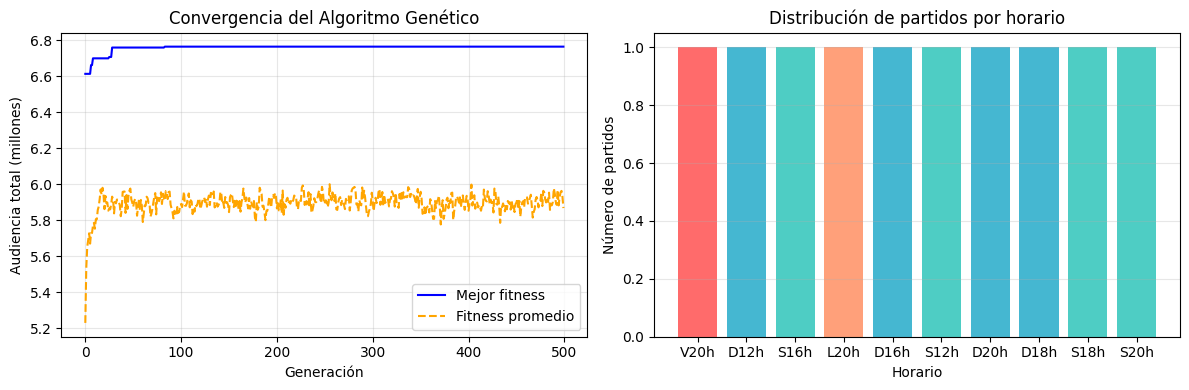

In [10]:
# ─────────────────────────────────────────
# VISUALIZACIÓN DE CONVERGENCIA
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de convergencia
axes[0].plot(hist_mejor, label='Mejor fitness', color='blue')
axes[0].plot(hist_avg, label='Fitness promedio', color='orange', linestyle='--')
axes[0].set_title('Convergencia del Algoritmo Genético')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('Audiencia total (millones)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de horarios en la mejor solución
from collections import Counter
conteo_horarios = Counter([f"{d}{h}h" for d, h in mejor_solucion])
labels = list(conteo_horarios.keys())
values = list(conteo_horarios.values())
colors = ['#FF6B6B' if 'V' in l else '#4ECDC4' if 'S' in l else '#45B7D1' if 'D' in l else '#FFA07A' for l in labels]
axes[1].bar(labels, values, color=colors)
axes[1].set_title('Distribución de partidos por horario')
axes[1].set_xlabel('Horario')
axes[1].set_ylabel('Número de partidos')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close()

Comparación entre solución aleatoria y Algoritmo Genético:
  Audiencia promedio (aleatoria): 5.1721 M
  Mejor audiencia (aleatoria):    6.6000 M
  Mejor audiencia (AG):           6.7650 M
  Mejora del AG sobre aleatorio:  +2.50%


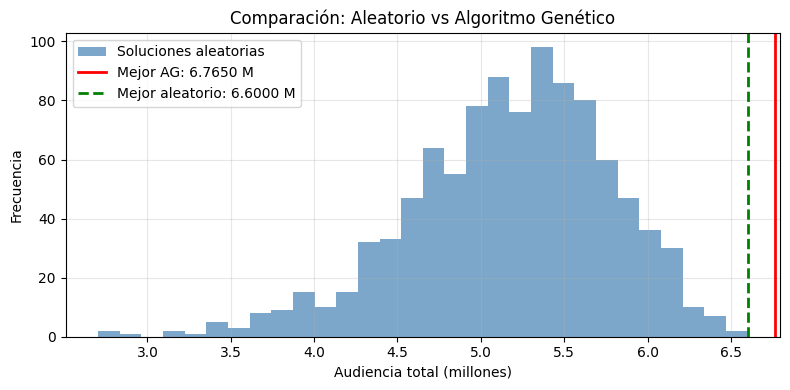

In [11]:
# ─────────────────────────────────────────
# COMPARACIÓN: SOLUCIÓN ALEATORIA vs AG
# ─────────────────────────────────────────

# Generar 1000 soluciones aleatorias y comparar
random.seed(1)
audiencias_aleatorias = [fitness(generar_individuo()) for _ in range(1000)]

print("Comparación entre solución aleatoria y Algoritmo Genético:")
print(f"  Audiencia promedio (aleatoria): {sum(audiencias_aleatorias)/len(audiencias_aleatorias):.4f} M")
print(f"  Mejor audiencia (aleatoria):    {max(audiencias_aleatorias):.4f} M")
print(f"  Mejor audiencia (AG):           {mejor_audiencia:.4f} M")
print(f"  Mejora del AG sobre aleatorio:  +{((mejor_audiencia - max(audiencias_aleatorias))/max(audiencias_aleatorias)*100):.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(audiencias_aleatorias, bins=30, color='steelblue', alpha=0.7, label='Soluciones aleatorias')
ax.axvline(mejor_audiencia, color='red', linewidth=2, label=f'Mejor AG: {mejor_audiencia:.4f} M')
ax.axvline(max(audiencias_aleatorias), color='green', linewidth=2, linestyle='--',
           label=f'Mejor aleatorio: {max(audiencias_aleatorias):.4f} M')
ax.set_title('Comparación: Aleatorio vs Algoritmo Genético')
ax.set_xlabel('Audiencia total (millones)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()